<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/> 

# Statistics for machine learning
---
<small>© COPYRIGHT 2026 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>


### Programmes

* Data Science Accelerator Workshop 3.1

### Learning Objectives

* Explain the purpose and structure of hypothesis testing including p-values and interpret the results
* Understand the danger of averages and why reporting only the mean can hide critical insights about inequality and risk
* Describe Simpson's paradox to show how data reasoning can go wrong
* Define Bayes' theorem and use it to compute probabilities
* Assess normality using histograms, Q-Q plots, and P-P plots to spot non-normal distributions
* Conduct formal normality test by applying Shapiro-Wilk and other statistical tests for normality
* Fix skewed and heavy-tailed distributions for better model performance
* Understanding why normality assumptions matter for regression, classification, and hypothesis testing




---



## Why Study Statistical Reasoning?

**The Core Problem:** Seeing data is not the same as understanding it.

When you observe data, you're observing measurements—not theories. For example:
- You see test scores correlate with years in school
- You see women's admission rates lower overall
- You see one drug appears more effective

**But none of these observations tell you WHY the correlation exists.**

### The Gap Between Measurement and Theory

There's a fundamental gap between **what we observe** (measurement) and **what we infer** (theory):

- **Measurement**: Light bouncing off objects, numbers in databases, statistical patterns
- **Theory**: Causal stories about how the world works (e.g., "schooling improves grades")

The data itself does **not** bridge this gap. A bent stick underwater looks identical whether the stick is bent or light is refracted. The same test score could indicate that schooling works, or that older students are inherently smarter, or both.

### Why You Need Probability Reasoning

To move from observation to understanding, we use **conditional probability**:

$$P(H|E) = \frac{P(E|H)P(H)}{P(E)}$$

This says: given your prior belief in a hypothesis ($P(H)$) and how consistent the evidence is with that hypothesis ($P(E|H)$), you can update your belief.

**Key insight:** All statistical reasoning requires **prior theories**. Data doesn't speak for itself.

## Example: The Bent Stick Problem

You observe a stick in a glass of water. It appears **bent**. Is it bent, or is it refraction?

Two competing hypotheses:
- $H_1$: The stick is physically bent
- $H_2$: The stick is straight, but light is refracted

**The observation alone is ambiguous.** You see identical light patterns either way.

To distinguish them, you need a **theory** about optics + **additional evidence** (e.g., pull the stick out of water—does it still look bent?).

**The lesson:** Data patterns don't determine which hypothesis is true. You need:
1. A prior theory of how the world works
2. Predictions derived from that theory
3. Evidence designed to test those predictions

But seeing is a kind of physical process, a way of measuring the world. When you see, light actually bounces off an object and hits your eyes. That light is ambiguous - a stick which really-is bent *looks* identical to one which isn't; the light is indistinguishable. The *evidence* alone does not settle the two competing hypothesis: A) the stick is bent, or B) the stick isn't bent. 

We don't see theories, we *infer* them. So there's really a gap between what we measure (physical things) and what we infer (*hypotheses*). The physical cannot, itself, provide a theory: we have to do it. And we have to have a systematic way of deciding between competing hypotheses given the evidence we observe. 



## The Language of Statistical Inference

As we transition from Data Analysis to Data Science, we move from **descriptive** statistics (summarising the past) to **probabilistic** modelling (predicting the future). This requires a shift from talking about "the data" to talking about "the distribution".




### From mathematical notation to Python implementation

Throughout your data science career, you'll encounter mathematical notation in research papers, textbooks, and statistical libraries. This section helps you **translate notation into Python**.

| Mathematical Notation | English | Python Example |
|---|---|---|
| $E[X]$ | Expected value (theoretical mean) | `np.mean(X)` or `np.random.normal().mean()` |
| $X \sim N(\mu, \sigma^2)$ | X is normally distributed with mean μ and variance σ² | `np.random.normal(loc=μ, scale=σ, size=n)` |
| $P(A\|B)$ | Probability of A given B (conditional probability) | `len(A[B]) / len(B)` or `conditional_prob(A, B)` |
| $\sum_{i=1}^{n} x_i$ | Sum of all x values from index 1 to n | `np.sum(x)` or `sum(x)` |

### Why You Need This Notation

- **Reading research**: Papers on ML algorithms use $E[X]$ instead of "expected value"
- **Communicating findings**: Stakeholders trust clear mathematical formulation
- **Understanding libraries**: SciPy and scikit-learn documentation uses this notation extensively



### Understanding distributions: from theory to data science

#### Why does this matter?

When you transition from **Data Analysis** (describing what happened) to **Data Science** (predicting what will happen), you shift from thinking about individual data points to thinking about the **underlying population distribution**.

In Python, you'll often work with `numpy.random` or `scipy.stats` to generate or model distributions. This notebook demonstrates:
- **Normal distributions**: Symmetric, bell-shaped (like human heights)
- **Power Law / Long-tail distributions**: Heavily skewed with extreme values (like company revenue, web traffic, or customer lifetime value)

#### Key insights for you

Many real-world business metrics **are not normally distributed**. Yet analysts often naively report the "average" as if it represents a typical value. As a data scientist, you must:
1. **Identify the true shape** of your data distribution
2. **Choose appropriate metrics** (mean vs. median vs. mode)
3. **Transform data when needed** (e.g., log-transform for ML models)
4. **Communicate findings** to non-technical stakeholders clearly



---

## Simpson's Paradox - why correlation does not mean causation

### How data analysis goes wrong

### Simpson's Paradox Explained

**Simpson's Paradox** occurs when a trend appears in aggregated data but reverses (or disappears) when data is split into subgroups.

This is **not** a statistical error or fluke—it's a fundamental insight about causation and confounding:

> **A variable hidden in your data (called a "confounding variable") can completely reverse the apparent relationship between two variables.**

### Why It Happens

When you aggregate data, you implicitly assume all groups are equally important. If one subgroup:
- Has a different underlying relationship AND
- Has a different size or composition

...then the subgroup's trend can be overwhelmed or reversed by the aggregate.

Suppose you gather test results across 84 months (7 years) at the same school. The children take the very same test each year, and we record their scores. We'll simulate some data but not worry about the code:

In [1]:
# Import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, skew, kurtosis, shapiro  
import seaborn as sns
import pandas as pd

from numpy import arange, concatenate
from numpy.random import normal 

In [2]:
months = np.arange(0, 84) 
cohort = months//12
scores = [-0.02*(m + 10) * months[m:m+12] + 100 + normal(5*m, 3, 12) for m in range(0, 84, 12)]

df = pd.DataFrame({'Months': months, 'Scores': concatenate(scores), 'Cohort': cohort})

In [3]:
df.head()

,Months,Scores,Cohort
0,0,97.728592,0
1,1,101.816529,0
2,2,102.938616,0
3,3,98.433487,0
4,4,97.588425,0


In [4]:
df.tail()

,Months,Scores,Cohort
79,79,334.223669,6
80,80,331.139526,6
81,81,328.436941,6
82,82,327.669026,6
83,83,321.545404,6


Let's look at the correlations:

In [5]:
df.corr().round(2)

,Months,Scores,Cohort
Months,1.00,0.97,0.99
Scores,0.97,1.00,0.99
Cohort,0.99,0.99,1.00


According to this, months in education has a *strong* positive correlation with performance/score. What is our conclusion? We find $P(E|H)=P(ScoresImproving|SchoolWorksWell)$ is high - does this mean schooling improves your education?

Let's plot this data, what do we see?

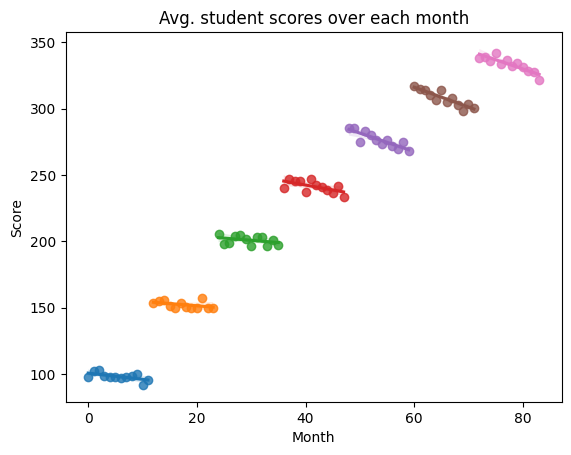

In [6]:
for m in range(0, 84, 12):
    plot = sns.regplot(x=months[m:m+12], y=scores[m//12])

plot.set(xlabel ="Month", 
         ylabel = "Score", 
         title ='Avg. student scores over each month');

where the colour corresponds to the year of the student.

Let's group by cohort and look at the correlation with the month of year:

In [8]:
# Calculate the correlation between Scores and Months, grouped by Cohort

cohorts = df['Scores'].groupby(df['Cohort']).corr(df['Months'])

In [9]:
cohorts

Cohort
0   -0.587452
1   -0.426577
2   -0.366653
3   -0.617515
4   -0.862308
5   -0.887510
6   -0.890615
Name: Scores, dtype: float64


Each year the students improve their scores overall - this caused us to see a positive correlation of months and score, since the values both increase together. 

However, when we look at each individual year group, they perform best at the beginning of each school year and by the end their scores worsen - this causes us to see a *negative correlation* with months when looking at individual year groups.




This is called "simpson's paradox" and it's one of the fundamental problems of scientific knowledge: the data alone does not tell you their cause. So here it *could* be legitimate to place them on the same plot, but it also *could not*: it depends on what the data means and on how the world actually works. It depends on our *prior theory*. 

In this case, *possibly*, the cause we track when we put all the data together (aging) isn't the cause we thought we were tracking (schooling), because the former effect is much larger than the later. Putting all this data together turns out to lead to the wrong conclusion here. This innocent mathematical operation of joining datasets turns out to invalidate the analysis in this case. 




There is no use of statistics which will solve this problem, it is beyond both statistics and any automated use of statistics. To determine what's going on here we need to *experiment* and thereby gain direct knowledge of the world.  By formualting hypotheses about the world, conducting experiments *based on those hypotheses* we can rule in-or-out various explainations. It is these explanations we require *before* we can intepret data. 


### What We Learned From Simpson's Paradox

#### Aggregate Data Shows
- **Positive correlation**: More months → Higher scores
- **Interpretation**: "School is working! Scores improve over time!"

#### Subgroup Analysis Shows (TRUTH)
- **Negative correlation in each year**: Within each cohort, scores decline over the year
- **Real interpretation**: "School is actually harming performance! Grades worsen each academic year!"

#### The Confounding Variable
**Age/Maturity** is the hidden variable:
- Older cohorts have inherently higher baseline scores (more mature)
- But within each cohort, students decline as the year progresses
- When we aggregate, the age effect dominates, masking the negative school effect

#### Critical insight: why does it matter?

$$\text{Correlation}_{aggregate} \ne \text{Correlation}_{subgroup}$$

**This isn't just about math—it's about causation:**
- The aggregate data suggests: "Months in school → Better scores" (FALSE causal claim)
- Subgroup data reveals: "Months in school → Worse scores" (TRUE causal claim)
- Without the subgroup analysis, you'd advocate for MORE schooling when you should advocate for LESS

### How to Avoid Simpson's Paradox

1. **Always check subgroups**: Don't rely on aggregate statistics alone
2. **Identify confounding variables**: What else might explain the pattern?
3. **Use prior theory**: Ask "Does this causal story make sense given what I know about the world?"
4. **Design experiments**: Sometimes observational data isn't enough—you need randomized trials to establish causation

---


## Group Discussion: The "Small Business Lifeline" Audit


**The Context:**

You are the lead Data Science advisory team for the Department for Business and Trade (DBT). The government recently launched the **"Small Business Lifeline"**, a new emergency grant and loan program. The Minister has handed you a preliminary evaluation report from a junior analyst and wants your recommendation: *Should we expand this program or shut it down?*

**The Analyst's Executive Summary:**

1. **Efficiency (Processing Times):** "The application portal is a success. The average time from application to funding is 12 days, safely under our 14-day target."
2. **Effectiveness (Default Rates):** "The new program is a failure. The overall loan default rate is 22%, compared to only 15% under our old standard loan program."

**The Hidden facts :**

* **Reality 1 :** 
    * The processing time data is not a normal "bell curve." It is heavily right-skewed. 85% of applications are auto-approved in **2 days**. 
    * 15% are flagged by a new algorithm for manual fraud review and take **60+ days**.
* **Reality 2 :** 
    * The new program intentionally lowered the barrier to entry, allowing highly vulnerable "Micro-businesses" to apply. Micro-businesses naturally fail at higher rates than "Medium" businesses.
    * Under the *New* Program: Micro defaults dropped from 40% to 30%. Medium defaults dropped from 10% to 5%.
    * The new program is actually *better* for both groups, but because it is flooded with high-risk Micro-businesses, the aggregate average looks worse!


---

### Your task

Discuss the following issues with your group to formulate your response to the Minister:

* The analyst reported a 12-day average wait time.

    * Why is the "Mean" a dangerous and misleading metric for this specific dataset? 
    * If the government plans its public relations campaign and call-center staffing around a "12-day wait," what real-world crisis are they about to create for the citizens in the long tail?

* Based on the overall default rate (22% vs 15%), the data *measures* the new program as a failure. However, your *theory* (incorporating business size) shows it's a success.

    * How do you explain to a non-technical Minister that the aggregate data is lying to them? 
    * What is the danger of making policy decisions without a causal theory?

* You were tasked with training a Machine Learning model to predict *which* applications will take the longest to process and you plan to feed the model the raw days (2, 2, 3... 60, 65).

    * Why might such data confuse the algorithm due to the extreme outliers. 
    * What transformation would you suggest taking and why would such transformation of these processing times make it easier for your model to learn?

---


## The Shape of Policy - Beyond the National Average

### Why 'Averages' Hide Inequality 

In the public sector, a "Mean" can be a deceptive metric. If the average wait time for a passport is 15 days, but 5% of citizens wait 6 months, the "Mean" suggests the policy is working while the "Long Tail" suggests a systemic failure.

To build robust public services, we must audit the **Four Moments** of our data:
1.  **Mean (Location):** The headline figure often used in Parliament.
2.  **Variance (Scale):** The consistency of service delivery across regions.
3.  **Skewness (Symmetry):** Are we failing a specific subset of the population (The 'Right Tail')?
4.  **Kurtosis (Tails):** The risk of 'Black Swan' events—systemic collapses or sudden surges in demand.

### Demo: The Political Risk of High Kurtosis

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, shapiro
# import statsmodels.api as sm

sns.set_theme(style="whitegrid")

# Scenario: Department A has consistent service. Department B has 'unstable' service.
np.random.seed(42)
dept_a_waits = np.random.normal(20, 2, 1000)  # Stable
dept_b_waits = np.random.standard_t(df=2.5, size=1000) + 20 # Prone to extreme delays

print(f"Dept A - Mean: {np.mean(dept_a_waits):.1f}, Kurtosis: {kurtosis(dept_a_waits):.2f}, Skew: {skew(dept_a_waits):.2f}")
print(f"Dept B - Mean: {np.mean(dept_b_waits):.1f}, Kurtosis: {kurtosis(dept_b_waits):.2f}, Skew: {skew(dept_a_waits):.2f}")



Dept A - Mean: 20.0, Kurtosis: 0.07, Skew: 0.12
Dept B - Mean: 20.0, Kurtosis: 24.62, Skew: 0.12


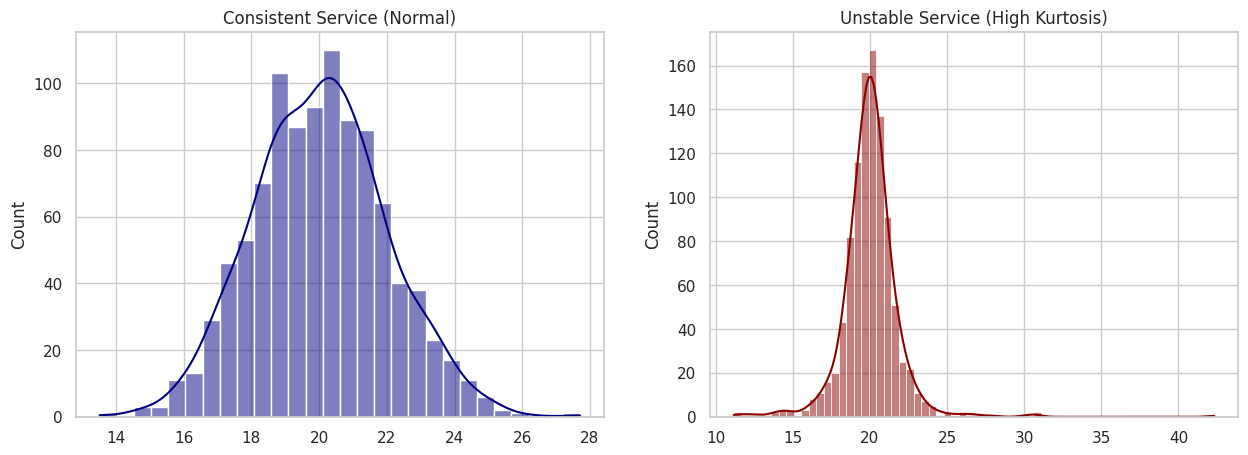

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(dept_a_waits, kde=True, ax=ax1, color='navy').set_title("Consistent Service (Normal)")
sns.histplot(dept_b_waits, kde=True, ax=ax2, color='darkred').set_title("Unstable Service (High Kurtosis)")
plt.show()

### Investigate the flaw of averages


In data science, you'll frequently encounter this scenario:
- **The Data Analyst** runs a quick analysis and reports: *"The average customer balance is £2,500"*
- **The Business Team** uses this to make strategic decisions
- **The Data Scientist** realizes the distribution is heavily skewed: many customers have £50, but a few have £50,000+

**The consequence?** Marketing campaigns target non-existent "average" customers. Product pricing misses real user segments. ML models trained on un-transformed data become biased toward outliers.


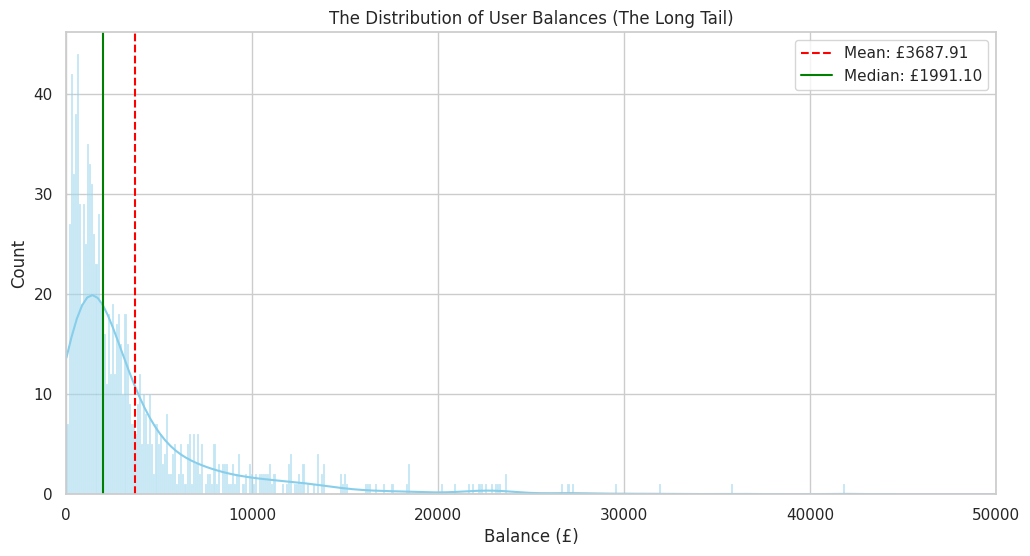

In [28]:
balances = np.random.lognormal(mean=3, sigma=1.2, size=1000) * 100

plt.figure(figsize=(12, 6))
sns.histplot(balances, kde=True, color="skyblue", bins=500)
plt.axvline(np.mean(balances), color='red', linestyle='--', label=f'Mean: £{np.mean(balances):.2f}')
plt.axvline(np.median(balances), color='green', linestyle='-', label=f'Median: £{np.median(balances):.2f}')
plt.title("The Distribution of User Balances (The Long Tail)")
plt.xlabel("Balance (£)")
plt.xlim(0, 50000)
plt.legend()
plt.show()

## Understanding Skewness, Log-Transforms, and ML Model Training

### What Is Skewness?

A **skewed distribution** is asymmetrical:
- **Right-skewed (Positive Skew)**: Long tail extends to the right. Mean > Median. Examples: income, company revenue, web page load times.
- **Left-skewed (Negative Skew)**: Long tail extends to the left. Mean < Median. Examples: exam scores (when most students perform well).

### The Log-Transform Trick

When data is heavily skewed, machine learning models struggle:
- Linear regression assumes roughly normal residuals
- Neural networks train more efficiently on normalized ranges
- Decision trees make suboptimal splits on extreme values

**Solution**: Take the logarithm of the data. This compresses large values and spreads out small ones, making the distribution more symmetric.

**In Python:**
```python
# Skewed data
original = np.random.lognormal(mean=3, sigma=1.2, size=1000)

# Log-transform it
log_transformed = np.log(original)
```

This simple transformation often improves model performance dramatically—a key technique in your data science toolkit.


### Mathematical Definitions

To understand these concepts formally, here are the mathematical definitions you'll encounter:

**Skewness** (measure of asymmetry):
$$\text{Skewness} = \frac{E[(X - \mu)^3]}{\sigma^3}$$
- Positive skewness (> 0): Right tail is longer
- Negative skewness (< 0): Left tail is longer
- Zero skewness: Symmetric distribution

**Kurtosis** (measure of tail heaviness):
$$\text{Excess Kurtosis} = \frac{E[(X - \mu)^4]}{\sigma^4} - 3$$
- Positive kurtosis: Heavy tails (more outliers) — "leptokurtic"
- Negative kurtosis: Light tails (fewer outliers) — "platykurtic"
- Zero kurtosis: Normal distribution — "mesokurtic"

**Log-Normal Distribution** ($\ln(X) \sim N(\mu, \sigma^2)$):
- If you take the natural log of a log-normal variable, it becomes normal
- Probability density: $f(x) = \frac{1}{x\sigma\sqrt{2\pi}} \exp\left(-\frac{(\ln x - \mu)^2}{2\sigma^2}\right)$

**Transformation Formula** (General Box-Cox):
$$y_\lambda = \begin{cases}
\frac{x^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\
\ln(x) & \text{if } \lambda = 0
\end{cases}$$
The algorithm finds the optimal $\lambda$ that maximizes normality.

### Interactive Visualisation: Comparing Multiple Distributions

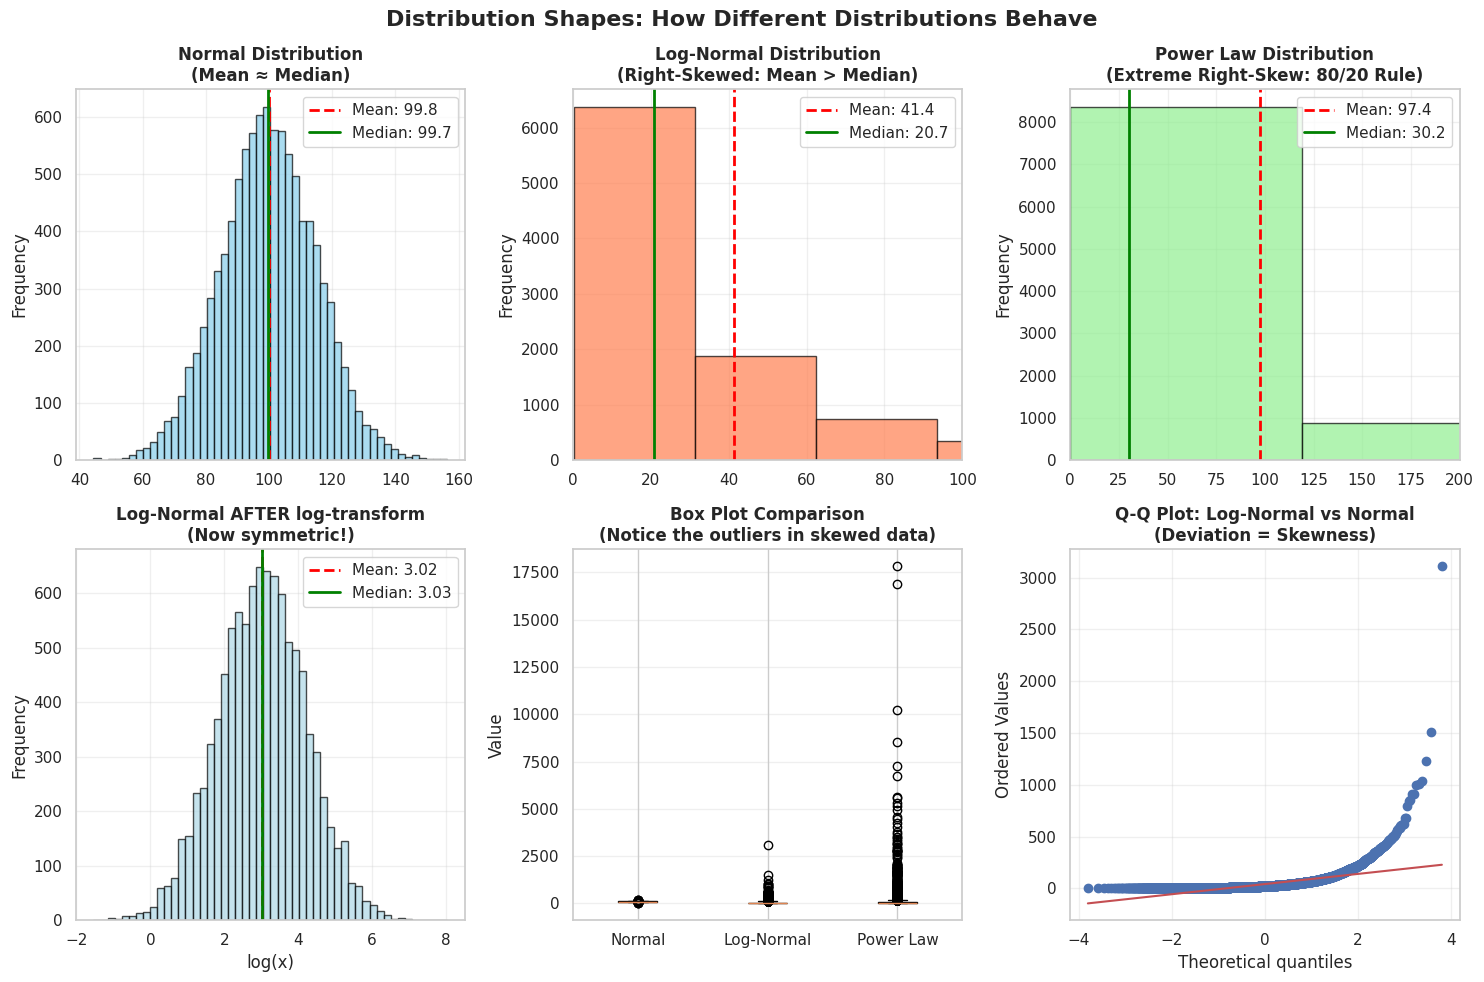

In [37]:
# Interactive Visualisation: Comparing Multiple Distributions

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution Shapes: How Different Distributions Behave', fontsize=16, fontweight='bold')

# 1. Normal Distribution
# This simulates a scenario where user balances are normally distributed around a mean value, with symmetric tails on either side. The mean and median are approximately equal, indicating no skewness.
# In real life, this could represent the distribution of user ages in a general population, where most users are around a certain age with fewer users at the very young and very old ends.
ax1 = axes[0, 0]
normal = np.random.normal(loc=100, scale=15, size=10000)
ax1.hist(normal, bins=50, color='skyblue', alpha=0.7, edgecolor='black')
ax1.axvline(np.mean(normal), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(normal):.1f}')
ax1.axvline(np.median(normal), color='green', linestyle='-', linewidth=2, label=f'Median: {np.median(normal):.1f}')
ax1.set_title('Normal Distribution\n(Mean ≈ Median)', fontweight='bold')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Log-Normal Distribution (Right-Skewed)
# This simulates user balances where most users have low balances but a few have very high balances, creating a long tail on the right.
# The mean is pulled to the right by the few high values, while the median remains closer to the bulk of the data, illustrating skewness.
# In real life, this could represent the distribution of user balances in a financial app, where most users have modest balances but a small percentage have very high balances.
ax2 = axes[0, 1]
lognormal = np.random.lognormal(mean=3, sigma=1.2, size=10000)
ax2.hist(lognormal, bins=100, color='coral', alpha=0.7, edgecolor='black') # Plot the histogram of the log-normal data with more bins to better visualize the long tail. The color and edgecolor parameters enhance the visual appeal and clarity of the histogram.
ax2.axvline(np.mean(lognormal), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(lognormal):.1f}')
ax2.axvline(np.median(lognormal), color='green', linestyle='-', linewidth=2, label=f'Median: {np.median(lognormal):.1f}')
ax2.set_title('Log-Normal Distribution\n(Right-Skewed: Mean > Median)', fontweight='bold')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xlim(0, 100)

# 3. Power Law / Pareto Distribution
# This simulates the 80/20 rule where a small percentage of users hold a large percentage of the total value (e.g., wealth distribution).
ax3 = axes[0, 2]
power_law = np.random.pareto(a=1.5, size=10000) * 50
ax3.hist(power_law, bins=150, color='lightgreen', alpha=0.7, edgecolor='black')
ax3.axvline(np.mean(power_law), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(power_law):.1f}')
ax3.axvline(np.median(power_law), color='green', linestyle='-', linewidth=2, label=f'Median: {np.median(power_law):.1f}')
ax3.set_title('Power Law Distribution\n(Extreme Right-Skew: 80/20 Rule)', fontweight='bold')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(alpha=0.3)
ax3.set_xlim(0, 200)

# 4. Effect of Log-Transform on Log-Normal
# Log-transforming a log-normal distribution should yield a normal distribution, demonstrating how transformations can help in normalizing skewed data.
ax4 = axes[1, 0]
log_transformed = np.log(lognormal)
ax4.hist(log_transformed, bins=50, color='lightblue', alpha=0.7, edgecolor='black') # Plot the histogram of the log-transformed data. This should show a more symmetric distribution compared to the original log-normal distribution, illustrating how the log transformation can help in normalizing skewed data.
ax4.axvline(np.mean(log_transformed), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(log_transformed):.2f}') # Add a vertical line for the mean of the log-transformed data, which should be close to zero if the original data is log-normal. 
    #This helps to visually confirm that the log transformation has normalized the data.
ax4.axvline(np.median(log_transformed), color='green', linestyle='-', linewidth=2, label=f'Median: {np.median(log_transformed):.2f}') # Add a vertical line for the median of the log-transformed data, which should also be close to zero. This further confirms that the log transformation has made the distribution more symmetric, as the mean and median are now closer together.
ax4.set_title('Log-Normal AFTER log-transform\n(Now symmetric!)', fontweight='bold')
ax4.set_xlabel('log(x)')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(alpha=0.3)

# 5. Box Plot Comparison - showing skewness visually
ax5 = axes[1, 1]
data_to_compare = [normal, lognormal, power_law]
bp = ax5.boxplot(data_to_compare, tick_labels=['Normal', 'Log-Normal', 'Power Law'], patch_artist=True) # Create a box plot to visually compare the distributions. The box plot will show the median, interquartile range, and potential outliers. Skewed distributions will have longer whiskers on one side and more outliers on the opposite side.
colors = ['skyblue', 'coral', 'lightgreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax5.set_ylabel('Value')
ax5.set_title('Box Plot Comparison\n(Notice the outliers in skewed data)', fontweight='bold')
ax5.grid(alpha=0.3, axis='y')

# 6. Quantile-Quantile (Q-Q) Plot: Normal vs Log-Normal
ax6 = axes[1, 2]
from scipy import stats
stats.probplot(lognormal, dist="norm", plot=ax6) # Generate a Q-Q plot comparing the log-normal data to a normal distribution. If the log-normal data is not normally distributed, the points will deviate from the reference line, especially in the tails, illustrating skewness.
ax6.set_title('Q-Q Plot: Log-Normal vs Normal\n(Deviation = Skewness)', fontweight='bold')
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [38]:
# For each distribution, we calculate and print the key summary statistics: mean, median, standard deviation, skewness, and kurtosis. This will help us understand the central tendency, variability, and shape of each distribution in more detail.
print("\n" + "="*80)
print("DISTRIBUTION SUMMARY STATISTICS")
print("="*80)
print(f"\nNORMAL DISTRIBUTION:")
print(f"  Mean: {np.mean(normal):.2f} | Median: {np.median(normal):.2f} | Std Dev: {np.std(normal):.2f}")
print(f"  Skewness: {stats.skew(normal):.4f} (≈0 = symmetric)")
print(f"  Kurtosis: {stats.kurtosis(normal):.4f} (≈0 = normal-like)")

print(f"\nLOG-NORMAL DISTRIBUTION:")
print(f"  Mean: {np.mean(lognormal):.2f} | Median: {np.median(lognormal):.2f} | Std Dev: {np.std(lognormal):.2f}")
print(f"  Skewness: {stats.skew(lognormal):.4f} (>0 = right-skewed)")
print(f"  Kurtosis: {stats.kurtosis(lognormal):.4f} (>0 = heavy tails)")

print(f"\nPOWER LAW DISTRIBUTION:")
print(f"  Mean: {np.mean(power_law):.2f} | Median: {np.median(power_law):.2f} | Std Dev: {np.std(power_law):.2f}")
print(f"  Skewness: {stats.skew(power_law):.4f} (>>0 = extremely right-skewed)")
print(f"  Kurtosis: {stats.kurtosis(power_law):.4f} (>>0 = extreme outliers)")

print(f"\nLOG-NORMAL AFTER LOG-TRANSFORM:")
print(f"  Mean: {np.mean(log_transformed):.2f} | Median: {np.median(log_transformed):.2f} | Std Dev: {np.std(log_transformed):.2f}")
print(f"  Skewness: {stats.skew(log_transformed):.4f} (≈0 = now symmetric!)")
print(f"  Kurtosis: {stats.kurtosis(log_transformed):.4f}")
print("="*80)


DISTRIBUTION SUMMARY STATISTICS

NORMAL DISTRIBUTION:
  Mean: 99.85 | Median: 99.72 | Std Dev: 15.01
  Skewness: 0.0166 (≈0 = symmetric)
  Kurtosis: -0.0160 (≈0 = normal-like)

LOG-NORMAL DISTRIBUTION:
  Mean: 41.40 | Median: 20.74 | Std Dev: 73.63
  Skewness: 11.9302 (>0 = right-skewed)
  Kurtosis: 349.2735 (>0 = heavy tails)

POWER LAW DISTRIBUTION:
  Mean: 97.43 | Median: 30.18 | Std Dev: 393.62
  Skewness: 23.7203 (>>0 = extremely right-skewed)
  Kurtosis: 854.3894 (>>0 = extreme outliers)

LOG-NORMAL AFTER LOG-TRANSFORM:
  Mean: 3.02 | Median: 3.03 | Std Dev: 1.19
  Skewness: -0.0131 (≈0 = now symmetric!)
  Kurtosis: -0.0164




### Group Lab: The Universal Service Guarantee Audit

**The Scenario:** You are the Data Science Audit team for a new Digital Identity rollout. The ministerial target is a **mean processing time of 10 minutes**. However, early data suggests some users are 'getting stuck' in the system for hours.

### Group Roles:
1.  **The Equity Visualiser:** Uses **QQ-Plots** and **Boxplots** to identify if specific 'citizen cohorts' are being left behind.
2.  **The Policy Advisor:** Interprets the risk. If the data isn't normal, how should the department change its public messaging?

### The Challenge:
Run the audit on the citizen data below. Determine if the 'Universal Service Guarantee' is being met or if the distribution hides a failure of equity.

### Discussion questions
**Policy Discussion Points:**
1.  Look at the 'Tail' in your boxplot. Is it ethical to report a 'Mean' of ~12 minutes when some citizens wait 80 minutes?
2.  If you wanted to predict wait times, why would a simple Linear Regression model perform poorly on this specific distribution?
3.  How do you fix the data set?

In [39]:
# GENERATING CITIZEN PROCESSING DATA
np.random.seed(99)
processing_times = np.concatenate([
    np.random.normal(10, 2, 900),      # Most citizens (Fast digital path)
    np.random.exponential(40, 100) + 20 # Citizens needing manual intervention (Slow path)
])

## YOUR TASK:
# 1. Calculate the 4 Moments (Mean, Variance, Skew, Kurtosis).

# 2. Visualise using a 3-panel dashboard (Hist, QQ-Plot, Boxplot).


In [42]:
print(f"Mean: {np.mean(processing_times):.1f}, Variance: {np.var(processing_times):2f}, Kurtosis: {kurtosis(processing_times):.2f}, Skew: {skew(processing_times):.2f}")

Mean: 15.5, Variance: 426.661212, Kurtosis: 30.07, Skew: 5.00


Mean:     15.47 minutes
Variance: 426.66
Skew:     5.00
Kurtosis: 30.07


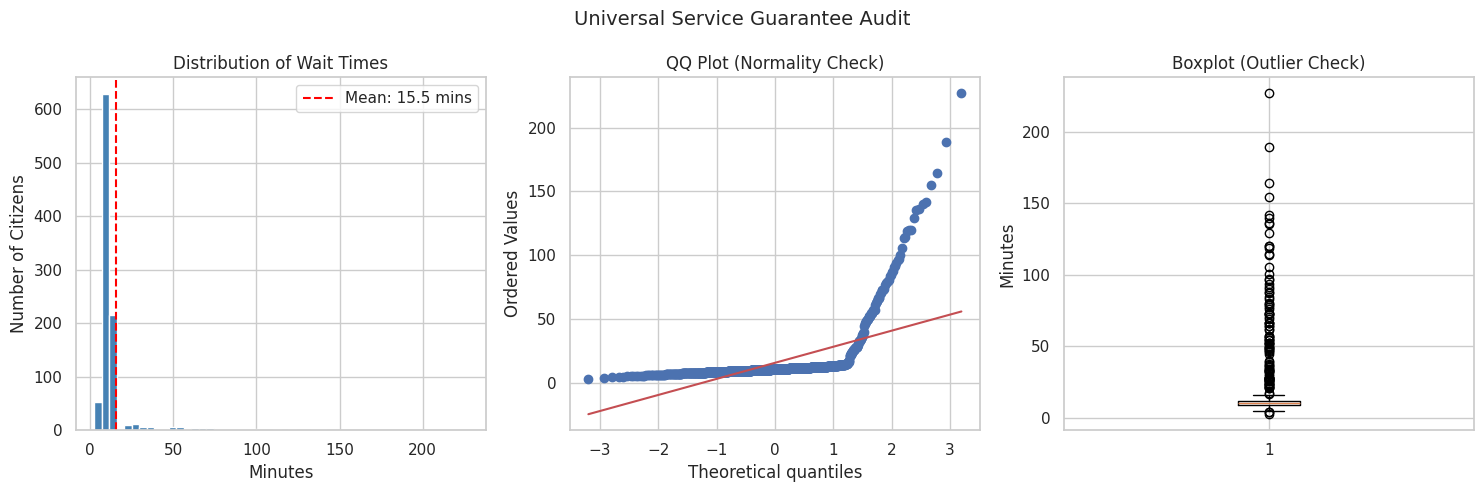

In [55]:
# GENERATING CITIZEN PROCESSING DATA
np.random.seed(99)
processing_times = np.concatenate([
    np.random.normal(10, 2, 900),      # Most citizens (Fast digital path)
    np.random.exponential(40, 100) + 20 # Citizens needing manual intervention (Slow path)
])
 
## YOUR TASK:
# 1. Calculate the 4 Moments (Mean, Variance, Skew, Kurtosis).
np.random.seed(99)
processing_times = np.concatenate([
    np.random.normal(10, 2, 900),       # Most citizens (Fast digital path)
    np.random.exponential(40, 100) + 20 # Citizens needing manual intervention (Slow path)
])
 
print(f"Mean:     {np.mean(processing_times):.2f} minutes")
print(f"Variance: {np.var(processing_times):.2f}")
print(f"Skew:     {stats.skew(processing_times):.2f}")
print(f"Kurtosis: {stats.kurtosis(processing_times):.2f}")
 
# 2. Visualise using a 3-panel dashboard (Hist, QQ-Plot, Boxplot).
 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Universal Service Guarantee Audit', fontsize=14)
 
# Panel 1 - Histogram
axes[0].hist(processing_times, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(processing_times), color='red', linestyle='--', label=f'Mean: {np.mean(processing_times):.1f} mins')
axes[0].set_title('Distribution of Wait Times')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Number of Citizens')
axes[0].legend()
 
# Panel 2 - QQ Plot
stats.probplot(processing_times, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot (Normality Check)')
 
# Panel 3 - Boxplot
axes[2].boxplot(processing_times, vert=True)
axes[2].set_title('Boxplot (Outlier Check)')
axes[2].set_ylabel('Minutes')
 
plt.tight_layout()
plt.show()

---

## Introduction to Normality

### What is Normality?

Normality refers to a distribution that follows the **normal (Gaussian) distribution**—the famous bell curve. This distribution is characterised by:

- **Symmetry:** The distribution is perfectly symmetrical around the mean
- **Single peak:** The mode, median, and mean coincide at the centre
- **Defined tails:** Approximately 68% of data falls within 1 standard deviation, 95% within 2, and 99.7% within 3

### Why Does Normality Matter for Model Building?

Many statistical models and machine learning algorithms make strong assumptions about the underlying data distribution:

1. **Linear Regression:** Assumes normally distributed residuals (errors). Violations lead to biased confidence intervals and incorrect hypothesis tests.

2. **Logistic Regression & Classification Models:** Assume normally distributed features in many theoretical frameworks. Skewed distributions can affect model performance.

3. **ANOVA & t-tests:** These hypothesis tests assume normality. Non-normal data can lead to incorrect p-values and false conclusions.

4. **Parametric Models (Gaussian Processes, some Bayesian methods):** Explicitly model data as normally distributed. Violations compromise predictions.

5. **Feature Engineering:** Non-normal features often require transformation (log transformation, Box-Cox transformation) before feeding into models.

6. **Confidence Intervals & Uncertainty Quantification:** Many methods for estimating model uncertainty rely on normality assumptions.

### When Non-Normality Becomes Critical

- **Sample size matters:** With large samples (n > 500), some models are robust to non-normality due to the Central Limit Theorem
- **Outliers and heavy tails:** Severely skewed or kurtotic data can mislead models
- **Prediction tasks:** For regression, non-normal residuals mean confidence intervals are unreliable
- **Business decisions:** If you're using model outputs to make resource allocation decisions (as in our public sector example), ignoring non-normality could lead to systematic bias against certain populations

### The Four Key Approaches to Testing Normality

1. **Visual Inspection:** Quick, intuitive, but subjective (0-5 min)
2. **Quantile-Quantile Plots:** Excellent for identifying where deviations occur (5-10 min)
3. **Statistical Tests:** Objective thresholds, but sensitive to large samples [OPTIONAL]
4. **Combined Approach:** Use multiple methods together for robust conclusions (this workshop)

---

## Visual Methods for Assessing Normality

### Method 1: Histograms with Normal Curve Overlay

A simple visual approach: plot the data and overlay a theoretical normal distribution. Deviations suggest non-normality.



In [59]:
from scipy.stats import shapiro, kstest, anderson, normaltest, norm
from scipy import stats

# Create different distributions to compare
np.random.seed(42)

# Normal distribution
normal_data = np.random.normal(loc=100, scale=15, size=500)

# Skewed distribution (right skew)
skewed_data = np.random.exponential(scale=2, size=500) + 50

# Kurtotic distribution (heavy tails)
kurtotic_data = np.random.standard_t(df=2.5, size=500) + 100




In [60]:
#Create a list of datasets, titles, and colours for iteration
datasets = [normal_data, skewed_data, kurtotic_data]
titles = ['Normal Distribution', 'Right-Skewed Distribution', 'Heavy-Tailed Distribution']
colours = ['navy', 'darkgreen', 'darkred']


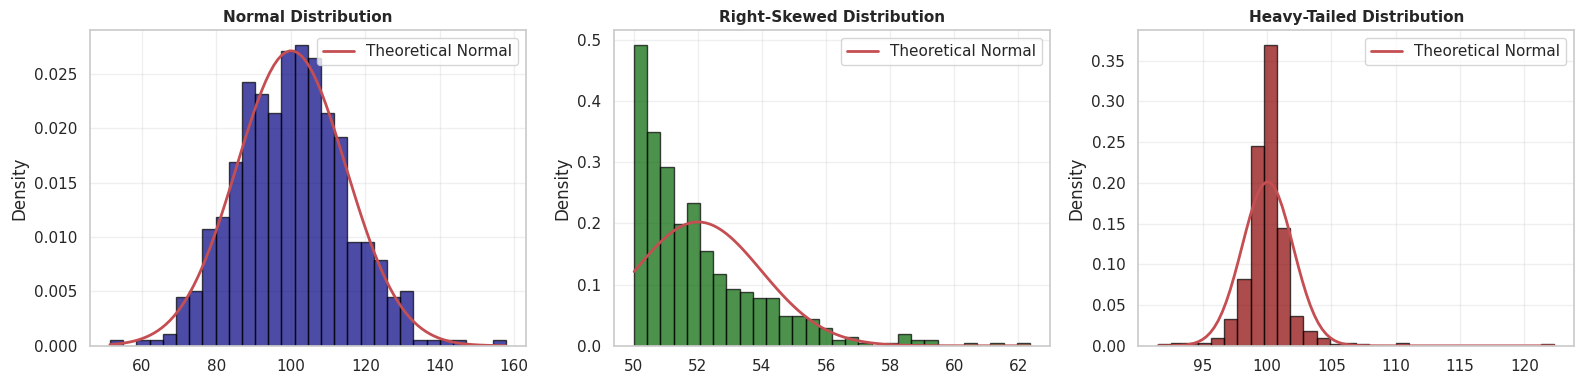

Visual Inspection Summary:
Normal data: The histogram closely follows the red normal curve
Skewed data: The histogram shows a right tail—doesn't match the normal curve
Kurtotic data: The histogram has extreme tails—data extends far from the curve


In [61]:
#Iterate through datasets and plot histograms with normal curve overlay
# Create figure with histograms + normal curve overlay
fig, axes = plt.subplots(1, 3, figsize=(16, 4)) # Create a 1x3 grid of subplots for the histograms of each distribution, allowing us to visually compare their shapes side by side.

for idx, (data, title, colour) in enumerate(zip(datasets, titles, colours)): # Iterate through each dataset, title, and colour for plotting
    ax = axes[idx]
    
    # Plot histogram
    n, bins, patches = ax.hist(data, bins=30, density=True, alpha=0.7, 
                                color=colour, edgecolor='black') # Plot the histogram of the data with density=True to show the probability density instead of frequency. This allows us to overlay the normal distribution curve on the same scale. The alpha parameter controls the transparency of the bars, and edgecolor adds a border to each bar for better visibility.
    
    # Overlay normal distribution curve
    mu, sigma = np.mean(data), np.std(data) #   Calculate mean and standard deviation for the normal curve overlay. This allows us to plot the theoretical normal distribution that best fits the data, which helps in visually assessing how closely the data follows a normal distribution.
    x = np.linspace(data.min(), data.max(), 100) # Generate x values for plotting the normal curve
    ax.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Theoretical Normal')
    # Set titles and labels
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(alpha=0.3)
# common layout adjustments
plt.tight_layout()
plt.show()

# Visual Inspection Summary
print("Visual Inspection Summary:")
print("Normal data: The histogram closely follows the red normal curve")
print("Skewed data: The histogram shows a right tail—doesn't match the normal curve")
print("Kurtotic data: The histogram has extreme tails—data extends far from the curve")


### Method 2: Q-Q (Quantile-Quantile) Plots 

A Q-Q plot compares sample quantiles against theoretical normal quantiles. If the data is normal, points should fall on a straight diagonal line. Deviations from the line indicate non-normality.

**Interpretation Guide:**
- **Straight line:** Data is likely normal ✓
- **S-shaped curve:** Data is skewed (asymmetric)
- **Curved at extremes:** Heavy tails (excess kurtosis)
- **Flicked ends:** Outliers or extreme values



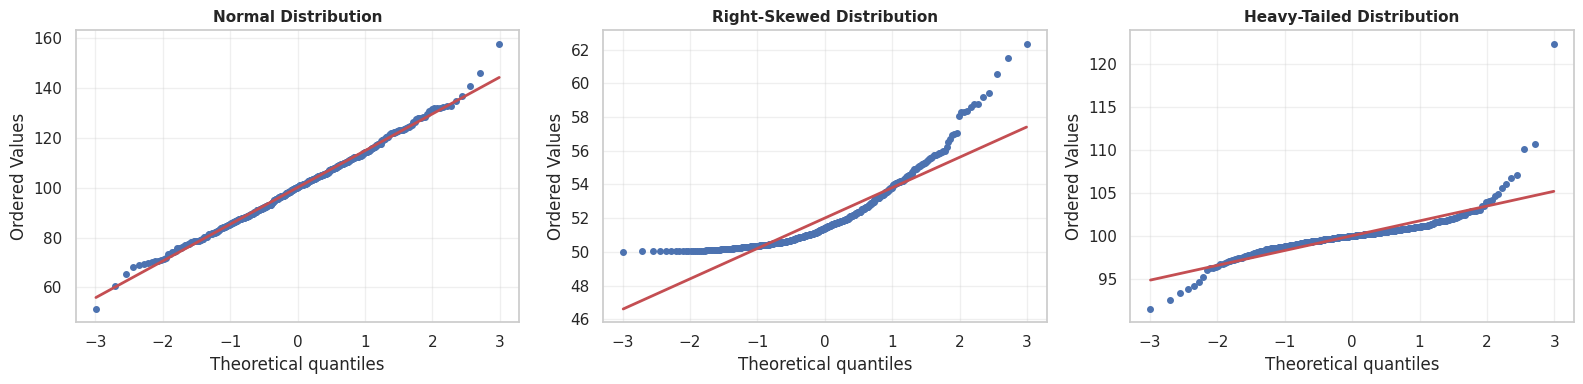


Q-Q Plot Interpretation:
Normal data: Points fall closely on the diagonal line
Skewed data: Points curve away from the line (S-shaped)
Kurtotic data: Points flick upward at both ends (heavy tails)


In [62]:
# Create Q-Q plots for the three distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4)) # Create a 1x3 grid of subplots for the Q-Q plots

for idx, (data, title, colour) in enumerate(zip(datasets, titles, colours)): # Iterate through each dataset, title, and colour for plotting
    ax = axes[idx]
    
    # Create Q-Q plot
    stats.probplot(data, dist="norm", plot=ax)  # Generate a Q-Q plot comparing the data to a normal distribution. The points represent the quantiles of the data plotted against the quantiles of a normal distribution. If the data is normally distributed, the points should approximately lie on the reference line (the red line in this case).
    ax.set_title(title, fontsize=11, fontweight='bold') # Set the title of each subplot to indicate which distribution is being plotted, using bold font for emphasis
    ax.get_lines()[0].set_markersize(4) # Make the points smaller for better visibility
    ax.get_lines()[1].set_linewidth(2) # Make the reference line thicker for better visibility
    ax.grid(alpha=0.3)

plt.tight_layout() # Adjust layout to prevent overlap
plt.show() # Display the Q-Q plots

print("\nQ-Q Plot Interpretation:")
print("Normal data: Points fall closely on the diagonal line")
print("Skewed data: Points curve away from the line (S-shaped)")
print("Kurtotic data: Points flick upward at both ends (heavy tails)")


---

## Group Challenge: Q-Q Plot Interpretation Challenge

### Your Task

Looking at the three Q-Q plots above, answer the following questions:

1. **Normal Distribution (Left Plot):**
   - How closely do the points follow the red diagonal line?
   - What percentage of points appear to deviate from the line?
   - Would you classify this data as normal? (YES / NO)

2. **Right-Skewed Distribution (Middle Plot):**
   - Describe the pattern of deviation from the diagonal
   - Does it curve upward or downward at the extremes?
   - What does this tell you about the distribution's shape?

3. **Heavy-Tailed Distribution (Right Plot):**
   - How do the points at the top and bottom of the plot deviate from the line?
   - Why might this be called a "heavy-tailed" distribution based on this plot?

### Discussion Points:

- Which distribution would be most problematic for a linear regression model? Why?
- In the right-skewed case, would you need to transform the data before modelling?
- If this were real government data (e.g., wait times), what would the heavy tails suggest about service reliability?

**Share your observations with your group**

In [ ]:
# Write your findings here: 
# for example, you might summarize the key differences in distribution shapes and what they imply about the underlying data.
# --- IGNORE ---


---

## Statistical Tests for Normality 

While visual inspection is useful, formal statistical tests provide objective thresholds. These tests use a null hypothesis: "The data comes from a normal distribution."

**Interpretation:** If the p-value < 0.05, we reject the null hypothesis—the data is **likely not normally distributed**.

### Overview of Common Normality Tests

| Test | Strengths | Limitations | When to Use |
|------|-----------|-----------|-----------|
| **Shapiro-Wilk** | Most powerful for small-medium samples | Less reliable for large n > 5000 | Default choice for n < 5000 |
| **Kolmogorov-Smirnov** | Works with any distribution | Less sensitive to deviations | When comparing to other distributions |
| **Anderson-Darling** | Good for extreme values | Complex interpretation | Heavy-tailed distributions |
| **D'Agostino-Pearson** | Combines skewness & kurtosis | Requires larger samples | When shape matters for your model |

### Test 1: Shapiro-Wilk Test

The most recommended test for typical data science applications. It's most powerful for samples of size 3 to 5000.

In [64]:
# Shapiro-Wilk Test
print("=" * 70)
print("SHAPIRO-WILK TEST FOR NORMALITY")
print("=" * 70)
print("\nNull Hypothesis (H₀): The data comes from a normal distribution")
print("Alternative (H₁): The data does NOT come from a normal distribution")
print("\nInterpretation: If p-value < 0.05, reject H₀ (data is not normal)\n")

results_sw = {} # Create an empty dictionary to store results of the Shapiro-Wilk test for each dataset
for data, title in zip(datasets, titles): # Iterate through each dataset and its corresponding title
    statistic, p_value = shapiro(data) # What is the function to perform the Shapiro-Wilk test?
    results_sw[title] = {'statistic': statistic, 'p_value': p_value}
    
    conclusion = "✓ Likely Normal" if p_value > 0.05 else "✗ NOT Normal" # Based on the p-value, determine if we reject or fail to reject the null hypothesis
    print(f"{title}:")
    print(f"  Test Statistic: {statistic:.6f}") # The test statistic indicates how closely the data follows a normal distribution (closer to 1 = more normal)
    print(f"  P-value: {p_value:.2e}")
    print(f"  Conclusion: {conclusion}\n") # The conclusion is based on the p-value threshold of 0.05, which is a common cutoff for statistical significance.


SHAPIRO-WILK TEST FOR NORMALITY

Null Hypothesis (H₀): The data comes from a normal distribution
Alternative (H₁): The data does NOT come from a normal distribution

Interpretation: If p-value < 0.05, reject H₀ (data is not normal)

Normal Distribution:
  Test Statistic: 0.996701
  P-value: 4.01e-01
  Conclusion: ✓ Likely Normal

Right-Skewed Distribution:
  Test Statistic: 0.828903
  P-value: 9.96e-23
  Conclusion: ✗ NOT Normal

Heavy-Tailed Distribution:
  Test Statistic: 0.754771
  P-value: 1.38e-26
  Conclusion: ✗ NOT Normal



### Test 2: Kolmogorov-Smirnov Test (KS-test)

Compares the empirical CDF of the sample to the theoretical normal CDF. Tests the maximum distance between them.

**Note:** Requires standardised data (mean=0, std=1) for this comparison.

In [66]:
# Kolmogorov-Smirnov Test
print("\n" + "=" * 70)
print("KOLMOGOROV-SMIRNOV TEST FOR NORMALITY")
print("=" * 70)
print("\nTesting against a standard normal distribution (mean=0, std=1)\n")

results_ks = {} # Create an empty dictionary to store results of the K-S test for each dataset
for data, title in zip(datasets, titles): # Iterate through each dataset and its corresponding title
    # Standardise the data
    standardised = (data - np.mean(data)) / np.std(data) # Standardising the data to have mean=0 and std=1 allows us to compare it against the standard normal distribution in the K-S test. This is important because the K-S test compares the empirical distribution of the data to a specified theoretical distribution (in this case, normal with mean=0 and std=1). By standardising, we ensure that any differences detected by the K-S test are due to the shape of the distribution rather than differences in scale or location.
    
    # Perform K-S test
    statistic, p_value = kstest(standardised, 'norm') # What is the function to perform the K-S test?
    results_ks[title] = {'statistic': statistic, 'p_value': p_value} # Store the test statistic and p-value in the results_ks dictionary for later reference
    
    conclusion = "✓ Likely Normal" if p_value > 0.05 else "✗ NOT Normal"
    print(f"{title}:")
    print(f"  Test Statistic (D): {statistic:.6f}")
    print(f"  P-value: {p_value:.2e}")
    print(f"  Conclusion: {conclusion}\n")



KOLMOGOROV-SMIRNOV TEST FOR NORMALITY

Testing against a standard normal distribution (mean=0, std=1)

Normal Distribution:
  Test Statistic (D): 0.027278
  P-value: 8.41e-01
  Conclusion: ✓ Likely Normal

Right-Skewed Distribution:
  Test Statistic (D): 0.155728
  P-value: 4.68e-11
  Conclusion: ✗ NOT Normal

Heavy-Tailed Distribution:
  Test Statistic (D): 0.147652
  P-value: 5.59e-10
  Conclusion: ✗ NOT Normal



---

## Key Takeaways

### Core Insights

#### 1. **Averages Hide Complexity**
The mean alone is insufficient. You must understand the **four moments** (mean, variance, skewness, kurtosis) to get a complete picture of your data's shape and behaviour.

**Real-world example:** A policy with mean outcome = 10 minutes is NOT the same whether all observations are between 8-12 minutes or some are 2 minutes and others are 95 minutes.

#### 2. **Visual Inspection is Your First Defence**
Before running any complex models:
- Plot a histogram + overlay the normal curve
- Create a Q-Q plot
- Look at the data with fresh eyes

Visual methods often reveal problems that formal tests miss and are interpretable to non-technical stakeholders.

#### 3. **Normality Testing Guides Model Selection**
- **If data is normal:** Parametric methods (linear regression, t-tests) are appropriate and efficient
- **If data is non-normal:** Consider transformations, non-parametric alternatives, or robust methods
- **Large samples:** Central Limit Theorem provides some protection against non-normality

#### 4. **Non-Normality ≠ Model Failure**
Non-normal data doesn't mean your model will fail, especially with:
- Large sample sizes (n > 500)
- Robust algorithms (tree-based models)
- Proper diagnostics and residual checking

However, it DOES mean you must be more careful and validate assumptions.

#### 5. **Context Matters More Than Rules**
The 'best' approach depends on:
- Your sample size
- Your model type
- The stakes of your decision (Is this resource allocation? Clinical diagnosis? Budget forecasting?)
- Your audience's technical understanding

---

### Practical Workflow for Any Data Science Project

```
1. Load your data
   ↓
2. Compute the four moments (mean, var, skewness, kurtosis)
   ↓
3. Create a histogram + overlay normal curve → Do they match?
   ↓
4. Create a Q-Q plot → Do points fall on the diagonal?
   ↓
5. Decision point:
   ├─ If YES to both → Data is likely normal, proceed with parametric methods
   └─ If NO to either → 
       ├─ Consider transformation (log, Box-Cox)
       ├─ Or use non-parametric methods
       └─ Or document the violation and proceed with caution
   ↓
6. Check your model's residuals using the same visual methods
```

---

### Decision Tree: What Should You Do?

```
Is your data normally distributed? (Visual check)
│
├─ YES → Use parametric methods (regression, t-test, ANOVA)
│         BUT: Still check residuals after modelling!
│
└─ NO → Three options:
         1. Transform the data (log, Box-Cox)
            Then test normality again
         
         2. Use non-parametric methods
            (Mann-Whitney U, Spearman correlation, tree models)
         
         3. Proceed with parametric methods
            BUT document the assumption violation
            AND use robust standard errors
```

---

### Common Mistakes to Avoid

❌ **Mistake 1:** Using only the mean to describe your data
✓ **Better:** Always report mean ± standard deviation AND median ± IQR

❌ **Mistake 2:** Assuming normality without checking
✓ **Better:** Always visualise first (histogram, Q-Q plot)

❌ **Mistake 3:** Automatically applying transformations
✓ **Better:** Check if transformation actually helps your downstream model

❌ **Mistake 4:** Reporting transformed model coefficients without backtransforming
✓ **Better:** If you log-transformed for modelling, exponentiate predictions for interpretation

❌ **Mistake 5:** Ignoring outliers because "the test says they're expected"
✓ **Better:** Investigate outliers (data quality issues? real phenomenon?)

---

### Resources for Going Deeper (Optional Reading)

**Visual Diagnostics:**
- [Understanding Q-Q Plots](https://en.wikipedia.org/wiki/Q%E2%80%93Q_plot) — Visual guide to interpreting Q-Q plots
- Seaborn documentation on `probplot` — For creating professional Q-Q plots

**Statistical Theory:**
- Shapiro-Wilk Test ([Wikipedia](https://en.wikipedia.org/wiki/Shapiro%E2%80%93Wilk_test))
- Anderson-Darling Test for heavy-tailed distributions

**Data Transformation:**
- Box-Cox Transformation ([SciPy documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.boxcox.html))
- Yeo-Johnson Transformation (works with negative values, unlike Box-Cox)

**Non-Parametric Alternatives:**
- Mann-Whitney U Test (alternative to independent t-test)
- Kruskal-Wallis Test (alternative to one-way ANOVA)
- Spearman's Rank Correlation (alternative to Pearson correlation)

---

### Final Reflection

> "The shape of your data matters as much as its centre. A good data scientist asks not just 'What is the average?' but 'What is the distribution?' "

Normality testing is not about following rules blindly—it's about understanding your data well enough to choose the right tools for your specific problem. Use these visual and statistical methods to be intentional about your modelling choices.


---

## Additional Resources for further learning

If you want to explore these concepts further, here are curated resources organised by learning style:

### **Interactive Visualisations (Learn by Playing)**

These tools let you adjust parameters and see distributions change in real-time:

- **Seeing Theory** (Interactive probability explorer) — https://seeing-theory.brown.edu/
  - Hands-on sandbox for understanding distributions visually
  - Try: "Probability Distributions" section to see how parameters affect shape

- **3Blue1Brown: Essence of Statistics** (YouTube playlist) — https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZZJF34jO
  - Beautifully animated explanations of distributions and concepts
  - Best for visual learners who want intuition first

- **StatQuest with Josh Starmer** (YouTube) — https://www.youtube.com/c/joshstarmer
  - Clear explanations of normal distribution, log-transform, and skewness
  - Search: "Normal Distribution Explained", "Log Transform"

- **Desmos: Distribution Explorer** — https://www.desmos.com/calculator/xxyvptl7gy
  - Interactive calculator to experiment with normal distribution parameters

- **Probability Distribution App** (Wolfram Alpha) — https://www.wolframalpha.com/
  - Type "normal distribution" or "log normal distribution" to see plots

### **Python Libraries & Documentation**

Learn how to generate and analyse distributions in code:

**Core Libraries:**
- **NumPy Random Module** — https://numpy.org/doc/stable/reference/random/index.html
  - Comprehensive guide to generating random samples from distributions
  - Essential for simulating data like we did above

- **SciPy Stats** — https://docs.scipy.org/doc/scipy/reference/stats.html
  - 70+ probability distributions built-in
  - Functions for skewness, kurtosis, quantiles

- **Matplotlib Visualisation** — https://matplotlib.org/stable/gallery/index.html
  - See histograms, box plots, KDE plots in the gallery

- **Seaborn** — https://seaborn.pydata.org/examples.html
  - Statistical visualizations with less code

**Tutorials & Guides:**
- **Real Python: NumPy Tutorial** — https://realpython.com/numpy-tutorial/
- **Towards Data Science Blog** — https://towardsdatascience.com/
  - Search: "probability distributions", "log transform", "skewness"

### **Log-Transforms & Feature Engineering**

Specific resources for understanding and applying transformations:

- **Box-Cox Transformation Explained** — https://www.analyticsvidhya.com/blog/2021/05/box-cox-transformation-technique-for-non-normal-data/
  - Visual comparison of transformations before/after
  - When to use log, square-root, Box-Cox

- **Scikit-learn: Preprocessing** — https://scikit-learn.org/stable/modules/preprocessing.html
  - PowerTransformer and QuantileTransformer for handling skewed data
  - Code examples ready to use

- **Feature Engineering for Machine Learning** — https://www.oreilly.com/library/view/feature-engineering-for/9781491953235/
  - Book chapter on handling skewed data
  - Real-world examples

### **Business Case Studies (See It in Action)**

Learn how real companies use distribution analysis:

- **Harvard Business Review: The Flaw of Averages** — https://hbr.org/1998/11/the-flaw-of-averages
  - Original article by Sam Savage showing why means mislead executives
  - Business scenarios you'll encounter in your career

- **Pareto Principle (80/20 Rule)** — https://en.wikipedia.org/wiki/Pareto_principle
  - Why power law distributions matter in business
  - Customer lifetime value, revenue concentration, effort allocation

- **Power Law Distributions in SEO/Web Analytics** — Search "power law website traffic"
  - Real data: traffic on websites follows Pareto distribution
  - Implications for marketing strategy

### **Mathematical Foundations (Go Deeper)**

For those who want to understand the math behind the concepts:

- **Khan Academy: Statistics & Probability** — https://www.khanacademy.org/math/statistics-probability
  - Free, step-by-step lessons on distributions, variance, skewness
  - Best for building mathematical intuition

- **Brilliant.org: Probability Course** — https://brilliant.org/courses/probability/
  - Interactive problem-solving approach
  - Learn by doing

- **Paul's Online Math Notes: Calculus** — https://tutorial.math.lamar.edu/
  - For understanding integration in probability density functions
  - Helps explain why $E[X] = \int_{-\infty}^{\infty} x \cdot f(x) \, dx$

- **MIT OpenCourseWare: Introduction to Probability** — https://ocw.mit.edu/courses/res-6-012-introduction-to-probability-spring-2018/
  - Full university course, free
  - Rigorous but accessible

### **Quick Reference Cheat Sheets**

- **Distribution Cheat Sheet** — Search "probability distribution cheat sheet"
  - One-page summary of when to use which distribution
  - Parameters and properties at a glance

- **SciPy Distribution Reference** — https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_continuous.html
  - Quick lookup for any distribution

---

